# Task 3 - Overcomplete EM Curriculum

**Goal:** try a larger latent grammar, start on shorter sentences, prune early, then widen the length cap.

**Strategy:**
1. Reuse the same `PCFG_EM` implementation from `task3.ipynb`
2. Initialize a larger grammar (`N_NT > 12`)
3. Train in phases with increasing `max_len`
4. Apply light early pruning inside each phase
5. Export an overcomplete CSV for inspection before forcing a 50-rule submission grammar


In [1]:
import collections
import csv
import time

import numpy as np

N_PRETERM = 26
START_SYMBOL = "S"
PRETERM_NAMES = [chr(ord('A') + i) for i in range(N_PRETERM)]
PRETERM_NAMES[ord('s') - ord('a')] = "PT_S"
TERM_TO_IDX = {chr(ord('a') + i): i for i in range(N_PRETERM)}


def sym_name(idx):
    if idx < N_PRETERM:
        return PRETERM_NAMES[idx]
    if idx == N_PRETERM:
        return START_SYMBOL
    return f"NT{idx - N_PRETERM}"


def load_corpus(path):
    sents = []
    with open(path) as f:
        for line in f:
            toks = line.strip().split()
            if toks:
                sents.append(np.array([TERM_TO_IDX[t] for t in toks], dtype=np.int32))
    return sents


def bpe_discover(sentences, max_merges=60, min_count=20):
    corpus = [s.tolist() for s in sentences]
    next_id = N_PRETERM
    rules, counts = [], []

    for step in range(max_merges):
        pair_freq = collections.Counter()
        for sent in corpus:
            for i in range(len(sent) - 1):
                pair_freq[(sent[i], sent[i + 1])] += 1
        if not pair_freq:
            break

        (left, right), freq = pair_freq.most_common(1)[0]
        if freq < min_count:
            break

        new_id = next_id
        next_id += 1

        new_corpus = []
        for sent in corpus:
            merged = []
            i = 0
            while i < len(sent):
                if i < len(sent) - 1 and sent[i] == left and sent[i + 1] == right:
                    merged.append(new_id)
                    i += 2
                else:
                    merged.append(sent[i])
                    i += 1
            new_corpus.append(merged)
        corpus = new_corpus

        rules.append((new_id, left, right))
        counts.append(freq)
        print(f"  [{step + 1:3d}] {sym_name(new_id):>6s} -> {sym_name(left):>6s} {sym_name(right):<6s}  freq={freq}")

    n_nt = next_id - N_PRETERM
    return rules, counts, n_nt, corpus


print("Utilities loaded.")
print(f"  Preterminals: {PRETERM_NAMES[0]}..{PRETERM_NAMES[-1]}")
print(f"  Terminal map sample: a->{TERM_TO_IDX['a']}, z->{TERM_TO_IDX['z']}")


Utilities loaded.
  Preterminals: A..Z
  Terminal map sample: a->0, z->25


In [2]:
class PCFG_EM:
    """
    CNF grammar with Inside-Outside EM.

    Symbol indices:
        0..25               preterminals (A..Z), fixed rules A->a, B->b, ...
        26                  S (start symbol)
        27..26+n_nt-1       other nonterminals

    rules[a, b, c] = P(NT_{a+26} -> Sym_b Sym_c)
    shape = (n_nt, N, N) where N = 26 + n_nt
    """

    def __init__(self, n_nt):
        self.n_nt = n_nt
        self.N = N_PRETERM + n_nt
        self.S = N_PRETERM
        self.rules = np.zeros((n_nt, self.N, self.N), dtype=np.float64)

    def init_from_bpe(self, bpe_rules, bpe_counts, noise=1e-3):
        rng = np.random.default_rng(42)
        self.rules[:] = noise * rng.random(self.rules.shape)

        if not bpe_rules:
            self._normalise()
            return

        last_bpe_id = bpe_rules[-1][0]
        remap = {i: i for i in range(N_PRETERM)}
        remap[last_bpe_id] = self.S
        fill = N_PRETERM + 1
        for new_id, _, _ in bpe_rules:
            if new_id != last_bpe_id:
                remap[new_id] = fill
                fill += 1

        for (new_id, left, right), cnt in zip(bpe_rules, bpe_counts):
            a = remap.get(new_id)
            l = remap.get(left)
            r = remap.get(right)
            if a is None or l is None or r is None:
                continue
            al = a - N_PRETERM
            if 0 <= al < self.n_nt and l < self.N and r < self.N:
                self.rules[al, l, r] += cnt

        self._normalise()

    def init_random(self, seed=42):
        rng = np.random.default_rng(seed)
        self.rules[:] = rng.random(self.rules.shape)
        self._normalise()

    def _normalise(self):
        for a in range(self.n_nt):
            s = self.rules[a].sum()
            if s > 0:
                self.rules[a] /= s

    def inside(self, sent):
        n = len(sent)
        alpha = np.zeros((self.N, n, n))
        for i in range(n):
            alpha[sent[i], i, i] = 1.0

        for width in range(2, n + 1):
            for i in range(n - width + 1):
                j = i + width - 1
                for k in range(i, j):
                    lv = alpha[:, i, k]
                    rv = alpha[:, k + 1, j]
                    bc = np.outer(lv, rv)
                    alpha[N_PRETERM:, i, j] += np.einsum('abc,bc->a', self.rules, bc)
        return alpha

    def outside(self, sent, alpha):
        n = len(sent)
        beta = np.zeros((self.N, n, n))
        beta[self.S, 0, n - 1] = 1.0

        for width in range(n, 1, -1):
            for i in range(n - width + 1):
                j = i + width - 1
                pb = beta[N_PRETERM:, i, j]
                if not np.any(pb):
                    continue
                for k in range(i, j):
                    r_a = alpha[:, k + 1, j]
                    l_a = alpha[:, i, k]
                    wr = np.einsum('alr,r->al', self.rules, r_a)
                    beta[:, i, k] += pb @ wr
                    wl = np.einsum('alr,l->ar', self.rules, l_a)
                    beta[:, k + 1, j] += pb @ wl
        return beta

    def em_step(self, sentences, max_len=30):
        counts = np.zeros_like(self.rules)
        ll = 0.0
        used = 0

        for sent in sentences:
            n = len(sent)
            if n < 2 or n > max_len:
                continue

            alpha = self.inside(sent)
            sp = alpha[self.S, 0, n - 1]
            if sp < 1e-300:
                continue

            ll += np.log(sp)
            used += 1
            beta = self.outside(sent, alpha)

            for width in range(2, n + 1):
                for i in range(n - width + 1):
                    j = i + width - 1
                    pb = beta[N_PRETERM:, i, j]
                    if not np.any(pb):
                        continue
                    for k in range(i, j):
                        lv = alpha[:, i, k]
                        rv = alpha[:, k + 1, j]
                        bc = np.outer(lv, rv)
                        counts += (pb[:, None, None] * self.rules * bc[None, :, :]) / sp

        for a in range(self.n_nt):
            s = counts[a].sum()
            if s > 0:
                self.rules[a] = counts[a] / s

        return ll, used

    def prune(self, threshold=0.02):
        self.rules[self.rules < threshold] = 0.0
        self._normalise()

    def count_rules(self, thr=1e-10):
        return int(np.sum(self.rules > thr))

    def export_csv(self, path):
        rows = []
        rid = 1
        for i in range(N_PRETERM):
            rows.append({
                'ID': rid,
                'LHS': PRETERM_NAMES[i],
                'LHS Type': 'preterminal',
                'RHS': chr(ord('a') + i),
                'Probability': 1.0,
            })
            rid += 1

        for a in range(self.n_nt):
            for b in range(self.N):
                for c in range(self.N):
                    p = self.rules[a, b, c]
                    if p > 1e-10:
                        rows.append({
                            'ID': rid,
                            'LHS': sym_name(a + N_PRETERM),
                            'LHS Type': 'nonterminal',
                            'RHS': f"{sym_name(b)} {sym_name(c)}",
                            'Probability': round(float(p), 6),
                        })
                        rid += 1

        with open(path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=['ID', 'LHS', 'LHS Type', 'RHS', 'Probability'])
            writer.writeheader()
            writer.writerows(rows)

        nt_count = sum(1 for r in rows if r['LHS Type'] == 'nonterminal')
        print(f"Exported {len(rows)} rules ({nt_count} nonterminal) -> {path}")
        return rows


print("PCFG_EM class loaded.")


PCFG_EM class loaded.


In [3]:
# Load corpus and initialize a larger grammar
CORPUS_PATH = 'sample/pcfg3_10k.txt'

corpus = load_corpus(CORPUS_PATH)
lengths = np.array([len(s) for s in corpus])
print(f"Loaded {len(corpus)} sentences")
print(f"  Length - min: {lengths.min()}, max: {lengths.max()}, mean: {lengths.mean():.1f}, median: {np.median(lengths):.0f}")

N_NT = 18
SEED = 42
USE_BPE_INIT = False
BPE_MAX_MERGES = 80
BPE_MIN_COUNT = 20

pcfg = PCFG_EM(N_NT)
if USE_BPE_INIT:
    short_seed = [s for s in corpus if 2 <= len(s) <= 20]
    bpe_rules, bpe_counts, bpe_n_nt, _ = bpe_discover(
        short_seed,
        max_merges=min(BPE_MAX_MERGES, N_NT),
        min_count=BPE_MIN_COUNT,
    )
    pcfg.init_from_bpe(bpe_rules, bpe_counts, noise=1e-3)
    print(f"\nPCFG initialized from BPE seed: discovered {bpe_n_nt} latent symbols in short sentences")
else:
    pcfg.init_random(seed=SEED)
    print("\nPCFG initialized from random seed")

print(f"  Nonterminals: {pcfg.n_nt}")
print(f"  Total symbols: {pcfg.N}")
print(f"  Initial non-zero rules: {pcfg.count_rules()}")
print(f"  Rule tensor size: {pcfg.n_nt} x {pcfg.N} x {pcfg.N} = {pcfg.n_nt * pcfg.N * pcfg.N:,}")
print(
    f"  Sentence counts by cutoff: len<=20: {sum(1 for s in corpus if len(s) <= 20)}, "
    f"len<=35: {sum(1 for s in corpus if len(s) <= 35)}, "
    f"len<=50: {sum(1 for s in corpus if len(s) <= 50)}, "
    f"len<=60: {sum(1 for s in corpus if len(s) <= 60)}"
)


Loaded 10000 sentences
  Length - min: 12, max: 80, mean: 30.7, median: 32

PCFG initialized from random seed
  Nonterminals: 18
  Total symbols: 44
  Initial non-zero rules: 34848
  Rule tensor size: 18 x 44 x 44 = 34,848
  Sentence counts by cutoff: len<=20: 3206, len<=35: 6247, len<=50: 8887, len<=60: 9441


In [4]:
# EM curriculum: shorter sentences first, then widen the cap
def run_em_schedule(pcfg, corpus, phases, seed=42):
    rng = np.random.default_rng(seed)
    corpus_sorted = sorted(corpus, key=len)
    history = []
    global_iter = 0

    for phase_idx, phase in enumerate(phases, start=1):
        name = phase['name']
        max_len = phase['max_len']
        em_iters = phase['iters']
        batch_size = phase.get('batch', 0)
        prune_every = phase.get('prune_every', 0)
        soft_prune = phase.get('soft_prune', 0.0)

        eligible = [s for s in corpus_sorted if 2 <= len(s) <= max_len]
        print(f"\nPhase {phase_idx}: {name}")
        print(f"  max_len={max_len}  iters={em_iters}  batch={batch_size or 'all'}  eligible={len(eligible)}")
        print(f"  early prune every {prune_every} iters at threshold {soft_prune:.4f}")

        for phase_iter in range(1, em_iters + 1):
            global_iter += 1
            if batch_size and batch_size < len(eligible):
                idxs = rng.choice(len(eligible), size=batch_size, replace=False)
                batch = [eligible[i] for i in idxs]
            else:
                batch = eligible

            t0 = time.time()
            ll, used = pcfg.em_step(batch, max_len=max_len)
            dt = time.time() - t0

            avg_ll = ll / max(used, 1)
            nr = pcfg.count_rules()
            history.append({
                'iter': global_iter,
                'phase': phase_idx,
                'phase_name': name,
                'phase_iter': phase_iter,
                'll': ll,
                'avg_ll': avg_ll,
                'used': used,
                'rules': nr,
                'time': dt,
                'max_len': max_len,
            })

            print(
                f"  [{global_iter:3d}] phase_iter={phase_iter:2d}/{em_iters}  "
                f"LL={ll:12.1f}  avg_LL={avg_ll:8.3f}  sents={used:4d}  rules={nr:5d}  {dt:5.1f}s"
            )

            if prune_every and soft_prune > 0 and phase_iter % prune_every == 0:
                before = pcfg.count_rules()
                pcfg.prune(threshold=soft_prune)
                after = pcfg.count_rules()
                print(f"         -> early prune: {before} -> {after} rules")

    return history


# Add a fourth phase with max_len=60 if you want to push further into the tail.
PHASES = [
    {'name': 'short_warmup', 'max_len': 20, 'iters': 15, 'batch': 2000, 'prune_every': 3, 'soft_prune': 0.0005},
    {'name': 'medium_expand', 'max_len': 35, 'iters': 15, 'batch': 2500, 'prune_every': 5, 'soft_prune': 0.0010},
    {'name': 'long_refine', 'max_len': 50, 'iters': 20, 'batch': 3000, 'prune_every': 5, 'soft_prune': 0.0015},
]

history = run_em_schedule(pcfg, corpus, PHASES, seed=SEED)
print(f"\nEM curriculum complete. Final rule count: {pcfg.count_rules()}")



Phase 1: short_warmup
  max_len=20  iters=15  batch=2000  eligible=3206
  early prune every 3 iters at threshold 0.0005
  [  1] phase_iter= 1/15  LL=    -98191.0  avg_LL= -49.096  sents=2000  rules=26028  129.3s
  [  2] phase_iter= 2/15  LL=    -65756.0  avg_LL= -32.878  sents=2000  rules=26027  127.3s
  [  3] phase_iter= 3/15  LL=    -47455.8  avg_LL= -23.728  sents=2000  rules=24669  129.1s
         -> early prune: 24669 -> 4883 rules
  [  4] phase_iter= 4/15  LL=    -41052.9  avg_LL= -20.537  sents=1999  rules= 4883   61.4s
  [  5] phase_iter= 5/15  LL=    -40671.0  avg_LL= -20.346  sents=1999  rules= 4879   61.2s
  [  6] phase_iter= 6/15  LL=    -40469.2  avg_LL= -20.255  sents=1998  rules= 4856   61.6s
         -> early prune: 4856 -> 4534 rules
  [  7] phase_iter= 7/15  LL=    -40053.4  avg_LL= -20.047  sents=1998  rules= 4534   51.7s
  [  8] phase_iter= 8/15  LL=    -39877.7  avg_LL= -19.949  sents=1999  rules= 4534   52.0s
  [  9] phase_iter= 9/15  LL=    -39482.4  avg_LL= -19

In [5]:
# Light final prune and overcomplete export
OUTPUT_CSV = 'pcfg3_overcomplete_curriculum.csv'
FINAL_PRUNE_THRESHOLD = 0.010
SHOW_TOP_N = 80

print(f"Applying final prune at {FINAL_PRUNE_THRESHOLD:.3f} before export...")
before = pcfg.count_rules()
pcfg.prune(threshold=FINAL_PRUNE_THRESHOLD)
after = pcfg.count_rules()
print(f"  rules: {before} -> {after}\n")

rows = pcfg.export_csv(OUTPUT_CSV)
binary_rows = [r for r in rows if r['LHS Type'] == 'nonterminal']
binary_rows = sorted(binary_rows, key=lambda row: row['Probability'], reverse=True)

print(f"\nTop {min(SHOW_TOP_N, len(binary_rows))} nonterminal rules after final prune:")
for r in binary_rows[:SHOW_TOP_N]:
    print(f"  {r['LHS']:>6s} -> {r['RHS']:<16s}  P={r['Probability']:.4f}")

print("\nNote: this notebook intentionally keeps an overcomplete grammar for inspection.")
print("If you want a submission-sized grammar later, compress it in a separate pass.")


Applying final prune at 0.010 before export...
  rules: 118 -> 86

Exported 112 rules (86 nonterminal) -> pcfg3_overcomplete_curriculum.csv

Top 80 nonterminal rules after final prune:
    NT17 -> NT12 NT16         P=1.0000
    NT10 -> I J               P=0.7427
     NT9 -> E I               P=0.7141
     NT8 -> I J               P=0.7115
     NT3 -> E F               P=0.7035
     NT2 -> Y Z               P=0.6978
    NT16 -> U V               P=0.6968
    NT13 -> Q R               P=0.6886
    NT14 -> M N               P=0.6880
     NT7 -> Q R               P=0.6591
     NT6 -> E I               P=0.5641
       S -> NT12 S            P=0.5250
    NT15 -> NT3 NT2           P=0.4533
    NT11 -> A B               P=0.4506
     NT5 -> NT11 NT6          P=0.3896
    NT15 -> NT11 NT6          P=0.3846
     NT1 -> NT2 NT7           P=0.3151
    NT14 -> O P               P=0.3120
    NT13 -> PT_S T            P=0.3114
    NT16 -> W X               P=0.3032
     NT2 -> A M               P=0.3

In [6]:
# Sanity check: full-corpus coverage and coverage by length bucket
TEST_N = min(1000, len(corpus))


def length_bucket(n):
    if n <= 20:
        return '<=20'
    if n <= 35:
        return '21-35'
    if n <= 50:
        return '36-50'
    return '51+'


test_sents = corpus[-TEST_N:]
test_ll = 0.0
parsed = 0
failed = 0
fail_by_len = collections.Counter()
bucket_total = collections.Counter()
bucket_parsed = collections.Counter()

for sent in test_sents:
    n = len(sent)
    if n < 2:
        continue

    bucket = length_bucket(n)
    bucket_total[bucket] += 1

    alpha = pcfg.inside(sent)
    sp = alpha[pcfg.S, 0, n - 1]
    if sp > 1e-300:
        test_ll += np.log(sp)
        parsed += 1
        bucket_parsed[bucket] += 1
    else:
        failed += 1
        fail_by_len[n] += 1

avg_ll = test_ll / max(parsed, 1)
coverage = parsed / max(parsed + failed, 1) * 100

print(f"Evaluated {parsed + failed} sentences")
print(f"  Parsed:   {parsed}  ({coverage:.1f}%)")
print(f"  Failed:   {failed}")
print(f"  Avg LL:   {avg_ll:.4f}")
print(f"  Rules:    {pcfg.count_rules()} nonterminal")

print("\nCoverage by length bucket:")
for label in ['<=20', '21-35', '36-50', '51+']:
    total = bucket_total[label]
    if total:
        cov = 100.0 * bucket_parsed[label] / total
        print(f"  {label:>5s}: {bucket_parsed[label]:4d}/{total:4d}  ({cov:5.1f}%)")

if failed > 0:
    print("\nFailed by sentence length (top 10):")
    for length, count in fail_by_len.most_common(10):
        print(f"  len={length:3d}: {count} failures")


Evaluated 1000 sentences
  Parsed:   998  (99.8%)
  Failed:   2
  Avg LL:   -29.9023
  Rules:    86 nonterminal

Coverage by length bucket:
   <=20:  345/ 345  (100.0%)
  21-35:  304/ 304  (100.0%)
  36-50:  247/ 248  ( 99.6%)
    51+:  102/ 103  ( 99.0%)

Failed by sentence length (top 10):
  len= 40: 1 failures
  len= 80: 1 failures


Phase boundaries:
  iter   1: short_warmup
  iter  16: medium_expand
  iter  31: long_refine


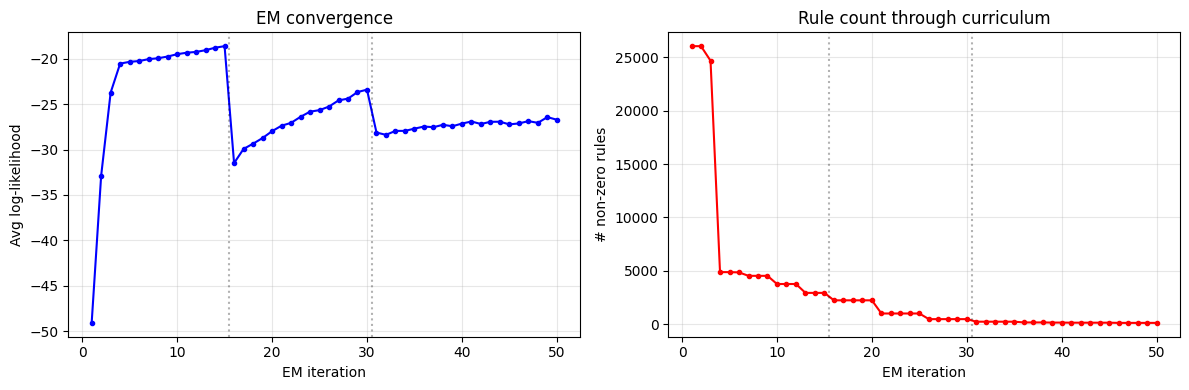

In [8]:
# Plot EM convergence with phase boundaries
import matplotlib.pyplot as plt

iters = [h['iter'] for h in history]
avg_lls = [h['avg_ll'] for h in history]
rule_counts = [h['rules'] for h in history]

phase_starts = []
for idx, entry in enumerate(history):
    if idx == 0 or entry['phase'] != history[idx - 1]['phase']:
        phase_starts.append((entry['iter'], entry['phase_name']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, avg_lls, 'b.-')
ax1.set_xlabel('EM iteration')
ax1.set_ylabel('Avg log-likelihood')
ax1.set_title('EM convergence')
ax1.grid(True, alpha=0.3)

ax2.plot(iters, rule_counts, 'r.-')
ax2.set_xlabel('EM iteration')
ax2.set_ylabel('# non-zero rules')
ax2.set_title('Rule count through curriculum')
ax2.grid(True, alpha=0.3)

for x, name in phase_starts[1:]:
    ax1.axvline(x=x - 0.5, color='k', linestyle=':', alpha=0.3)
    ax2.axvline(x=x - 0.5, color='k', linestyle=':', alpha=0.3)

print('Phase boundaries:')
for x, name in phase_starts:
    print(f"  iter {x:3d}: {name}")

plt.tight_layout()
plt.show()
